In [1]:
import cv2 
from matplotlib import pyplot as plt
from PIL import Image
import pickle
import shutil
import os
import glob
import csv
import numpy as np
from collections import OrderedDict


In [3]:
pickle_file = open('/media/osero/SamsungSSD/pickles/features_right_hand_frames_large.pickle', 'rb')
features,labels = pickle.load(pickle_file)

In [4]:
# Step 4: Process All Videos in the Dataset
# Set paths to your video dataset and labels
video_folder = "/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256" 
video_labels = []  # Populate this with the corresponding labels for each video
process_count = 0

folder_path_list = []
sorted_features = []
for label_folder in os.listdir(video_folder):
    full_label_folder = os.path.join(video_folder, label_folder)
    label = int(label_folder)
    # print("process_count: ", process_count, ' , label: ', label)
    for sample_folder in os.listdir(full_label_folder):
        full_sample_folder = os.path.join(full_label_folder, sample_folder)
        folder_path_list.append(full_sample_folder)
        feature_path_list = []
        for image_file in os.listdir(full_sample_folder):
            full_image_file = os.path.join(full_sample_folder, image_file)
            feature_path_list.append(full_image_file)
        # image = Image.open(full_image_file)
        #     image_list.append(image)
        # video_embedding = extract_video_embedding(image_list)
        # video_embeddings.append(video_embedding)
        # video_labels.append(label)

        feature_dict=dict(zip(feature_path_list, features[process_count]))
        ordered_feature_dict = OrderedDict(sorted(feature_dict.items()))
        ordered_feature_single_image = list(ordered_feature_dict.values())
        sorted_features.append(ordered_feature_single_image)
        process_count += 1
            
ccc = 4
        

In [5]:
zipped_pickle_feature_dict=dict(zip(folder_path_list, sorted_features))
ordered_pickle_feature_dict= OrderedDict(sorted(zipped_pickle_feature_dict.items()))
zipped_pickle_labels_dict=dict(zip(folder_path_list, labels))
ordered_pickle_labels_dict= OrderedDict(sorted(zipped_pickle_labels_dict.items()))

ordered_features = list(ordered_pickle_feature_dict.values())
ordered_labels = list(ordered_pickle_labels_dict.values())
ordered_paths = list(ordered_pickle_feature_dict.keys())

ccc = 4

In [6]:

with open('/media/osero/SamsungSSD/pickles/features_right_hand_frames_large_ordered.pickle', 'wb') as handle:
    pickle.dump((ordered_paths, ordered_features, ordered_labels), handle, protocol=pickle.HIGHEST_PROTOCOL)

In [9]:
# LOCATION : https://github.com/purnasai/Dino_V2
import torch
from torchvision import models, transforms
import cv2
import os
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from PIL import Image
import pickle

os.environ["XFORMERS_DISABLED"] = "1" # Switch to enable xFormers
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# Load DINO ViT model from torchvision (for example, ViT small or base model trained with DINO)
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14').to(device)
model.eval()

# Define transform to match the input size for the model
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Step 3: Function to Extract Embeddings for a List of Frames
def extract_video_embedding(image_list):
    """Extracts and averages embeddings for a list of frames."""
    embeddings = []
    with torch.no_grad():
        for image in image_list:
            input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension
            features = model(input_tensor)
            embeddings.append(features.squeeze().cpu().numpy())
    return embeddings

# Step 4: Process All Videos in the Dataset
# Set paths to your video dataset and labels
video_folder = "/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256" 
video_labels = []  # Populate this with the corresponding labels for each video
video_embeddings = []
process_count = 0
for label_folder in sorted(os.listdir(video_folder)):
    process_count += 1
    if (process_count > 3):
        break
    full_label_folder = os.path.join(video_folder, label_folder)
    label = int(label_folder)
    print("process_count: ", process_count, ' , label: ', label)
    for sample_folder in sorted(os.listdir(full_label_folder)):
        full_sample_folder = os.path.join(full_label_folder, sample_folder)
        print("full_sample_folder: ", full_sample_folder)
        image_list = []
        for image_file in sorted(os.listdir(full_sample_folder)):
            full_image_file = os.path.join(full_sample_folder, image_file)
            image = Image.open(full_image_file)
            image_list.append(image)
            
        video_embedding = extract_video_embedding(image_list)
        video_embeddings.append(video_embedding)
        if (video_embedding[3] != ordered_features[len(video_embeddings)-1][3]).all():
            print('@@@@@@@@@@@@@@@@@@@3')
        if (video_embedding[5] != ordered_features[len(video_embeddings)-1][5]).all():
            print('@@@@@@@@@@@@@@@@@@@5')
        if (video_embedding[10] != ordered_features[len(video_embeddings)-1][10]).all():
            print('@@@@@@@@@@@@@@@@@@@10')
        video_labels.append(label)

Using cache found in /home/osero/.cache/torch/hub/facebookresearch_dinov2_main


process_count:  1  , label:  1
full_sample_folder:  /media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_2_001
full_sample_folder:  /media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_2_002
full_sample_folder:  /media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_2_003
full_sample_folder:  /media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_2_004
full_sample_folder:  /media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_4_001
full_sample_folder:  /media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_4_002
full_sample_folder:  /media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_4_003
full_sample_folder:  /media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_4_004
full_sample_folder:  /media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_4_005
full_sample_folder:  /media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_4_006
full_sample_folder:  /media/osero/SamsungSSD/CMPE

KeyboardInterrupt: 

In [ ]:
pickle_file1 = open('/media/osero/SamsungSSD/pickles/features_right_hand_frames_large_ordered.pickle', 'rb')
paths1, features1,labels1 = pickle.load(pickle_file1)
print(paths1[0:10])
print(labels1[0:10])
print(paths1[-10:])
print(labels1[-10:])

['/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_2_001', '/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_2_002', '/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_2_003', '/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_2_004', '/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_4_001', '/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_4_002', '/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_4_003', '/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_4_004', '/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_4_005', '/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0001/User_4_006']
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
['/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0744/User_6_001', '/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0744/User_6_002', '/media/osero/SamsungSSD/CMPE_SSD/frame-hand_right-c256/0744/User_6_003', '/med

## Active Frames

In [10]:

def get_active_frames(input_raw) -> np.ndarray:
    threshold = (
        (((input_raw["pose"]["left_hip"][:, 1] + input_raw["pose"]["right_hip"][:, 1]) / 2 )* 7)
        + input_raw["pose"]["nose"][:, 1]
    ) / 10

    active_frames = (
        np.minimum(
            input_raw["hand_left"]["left_lunate_bone"][:, 1],
            input_raw["hand_right"]["right_lunate_bone"][:, 1],
        )
        < threshold
    )

    active_frame_indices = np.argwhere(active_frames).squeeze()
    return active_frame_indices

In [ ]:
file = open('/media/osero/SamsungSSD/CMPE_SSD/mmpose-full/0001/User_2_001.pickle', 'rb')
input_raw = pickle.load(file)

active_frame_indices = get_active_frames(input_raw)
input_raw = {
    **input_raw["pose"],
    **input_raw["face"],
    **input_raw["hand_left"],
    **input_raw["hand_right"],
}

print('active_frame_indices: ', active_frame_indices)
print('Len check: ', (len(active_frame_indices)-1) == (max(active_frame_indices) - min(active_frame_indices)))
ccc = 3
# input = np.array([input_raw[jn] for jn in nodes]).transpose((1, 0, 2))
# active_frame_indices = (
#     active_frame_indices
#     if active_frame_indices.size > 10
#     else np.arange(0, len(input))
# )

# input = input[active_frame_indices, ...]

In [23]:
## Analyze active frame algorithm
from collections import Counter
import pickle
import numpy as np

pickle_file = open('/media/osero/SamsungSSD/pickles/features_face_frames_small_ordered.pickle', 'rb')
paths, features, labels = pickle.load(pickle_file)

pose_pickle_folder = '/media/osero/SamsungSSD/CMPE_SSD/mmpose-full/'

def get_active_frames_from_pickle(input_raw) -> np.ndarray:
    threshold = (
        (((input_raw["pose"]["left_hip"][:, 1] + input_raw["pose"]["right_hip"][:, 1]) / 2 )* 6)
        + input_raw["pose"]["nose"][:, 1] * 4
    ) / 10

    active_frames = (
        np.minimum(
            input_raw["hand_left"]["left_lunate_bone"][:, 1],
            input_raw["hand_right"]["right_lunate_bone"][:, 1],
        )
        < threshold
    )

    active_frame_indices = np.argwhere(active_frames).squeeze()
    return active_frame_indices, len(input_raw["hand_left"]["left_lunate_bone"][:, 1])


def get_active_frames(label_name, sample_name):
    pickle_file_name = f"{pose_pickle_folder}/{label_name}/{sample_name}.pickle"
    file = open(pickle_file_name, 'rb')
    input_raw = pickle.load(file)
    return get_active_frames_from_pickle(input_raw)

missings_user_names=[]
missings_paths=[]
missing_active_frame_count_list = []
total_frame_count = 0
total_active_frame_count = 0
for path in paths:
    splited_paths = path.split('/')
    active_frame_indices, frame_count = get_active_frames(splited_paths[-2],splited_paths[-1])
    total_frame_count += frame_count
    total_active_frame_count += active_frame_indices.size
    if active_frame_indices.size < 10:    
        missing_active_frame_count_list.append(active_frame_indices.size)
        user_name = f'{splited_paths[-1].split("_")[0]}_{splited_paths[-1].split("_")[1]}'
        missings_user_names.append(user_name)
        missings_paths.append(path.rsplit('/', 1)[0])
        print(path)
        print('active_frame_indices: ', active_frame_indices)

occurrences = Counter(missings_paths)
user_name_occurrences = Counter(missings_user_names)
active_frame_occurrences = Counter(missing_active_frame_count_list)
print('total_frame_count: ', total_frame_count, ' total_active_frame_count: ', total_active_frame_count, ' ratio: ', total_active_frame_count/total_frame_count)
print('missing_count: ', len(missings_paths))
for item, count in occurrences.items():
    print(f"{item}: {count}")

for item, count in user_name_occurrences.items():
    print(f"{item}: {count}")

for item, count in active_frame_occurrences.items():
    print(f"{item}: {count}")

/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256/0002/User_4_011
active_frame_indices:  [29 30 31 32 33 34]
/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256/0009/User_4_005
active_frame_indices:  [16 19 20 21 22 29]
/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256/0011/User_4_001
active_frame_indices:  [23 24 25 26 27 28 29 30]
/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256/0011/User_4_003
active_frame_indices:  [29 30 31 32 33 34 35 36]
/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256/0011/User_4_004
active_frame_indices:  [26 27 28 29 30 31 32 33 34]
/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256/0011/User_6_002
active_frame_indices:  []
/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256/0011/User_6_003
active_frame_indices:  [41 42 43 44 45]
/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256/0011/User_6_004
active_frame_indices:  [20 21 22 23 24 28 29 30 31]
/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256/0011/User_6_005
active_frame_indices:  []
/media/osero/SamsungSSD/CMPE_SSD/fr

## Split pickle to test & train

In [1]:
import pickle

pickle_file = open('/media/osero/SamsungSSD/pickles/features_right_hand_frames_large_ordered.pickle', 'rb')
paths, features, labels = pickle.load(pickle_file)

train_paths = []
train_features = []
train_labels = []
test_paths = []
test_features = []
test_labels = []

for i, path in enumerate(paths):
    user_name = paths[i].split('/')[-1].lower()
    if 'user_4' in user_name:
        test_paths.append(paths[i])
        test_features.append(features[i])
        test_labels.append(labels[i])
    else:
        train_paths.append(paths[i])
        train_features.append(features[i])
        train_labels.append(labels[i])


with open('/media/osero/SamsungSSD/pickles/features_right_hand_frames_large_train.pickle', 'wb') as handle:
    pickle.dump((train_paths, train_features, train_labels), handle, protocol=pickle.HIGHEST_PROTOCOL)


with open('/media/osero/SamsungSSD/pickles/features_right_hand_frames_large_test.pickle', 'wb') as handle:
    pickle.dump((test_paths, test_features, test_labels), handle, protocol=pickle.HIGHEST_PROTOCOL)

cc = 4

In [2]:
import torch

results = torch.load('/home/osero/Desktop/CMPE/dinov2/classsification/lstm/lstm_results/LSTM_RL_2024-11-19_01-07-35.pth')

cc = 4

## gggggggggggggggggggg

In [ ]:
from IPython.display import display, Javascript

def save_notebook():
    display(Javascript('IPython.notebook.save_checkpoint();'))

# Call the function to save the notebook
save_notebook()


<IPython.core.display.Javascript object>

In [ ]:
import os
import urllib
import datetime
from time import gmtime, strftime

print(strftime("%Y-%m-%d_%H-%M-%S", gmtime()))

# # Get the current notebook file path
# def get_notebook_name():
#     connection_file = os.path.basename(notebookapp.list_running_servers()[0]['connection_file'])
#     notebook_name = urllib.parse.unquote(connection_file).split('-')[0]
#     return notebook_name

# Save the notebook
def save_notebook():
    notebook_name = 'arrange_pickles.ipynb'
    os.system(f'jupyter nbconvert --to notebook --execute --inplace {notebook_name}')
    print(f"Notebook {notebook_name} has been saved.")

save_notebook()

In [33]:
import shutil
print(strftime("%Y-%m-%d_%H-%M-%S", gmtime()))

# Define your file name
original_file = "arrange_pickles.ipynb"
copy_file = "your_notebook_copy.ipynb"

# Copy the file
shutil.copy(original_file, copy_file)

2024-11-20_00-41-52


'your_notebook_copy.ipynb'

In [35]:
import nbformat

print(strftime("%Y-%m-%d_%H-%M-%S", gmtime()))

def save_notebook():
    # Get the current notebook file path
    notebook_filename = "arrange_pickles.ipynb"  # Replace with your notebook's name

    # Load the notebook
    with open(notebook_filename, 'r') as f:
        notebook_content = nbformat.read(f, as_version=4)

    # Save the notebook
    with open(notebook_filename, 'w') as f:
        nbformat.write(notebook_content, f)

    print(f"Notebook {notebook_filename} has been saved.")

save_notebook()

2024-11-20_00-43-26
Notebook arrange_pickles.ipynb has been saved.


## Deephand

In [4]:
import numpy as np

z = np.load('/media/osero/SamsungSSD/deephand-lefthand/0001/User_2_001.npz')
print(z.f.features.shape)

print(z.f.features[0])
ddd = 5

(65, 1024)
[0.0000000e+00 0.0000000e+00 9.4030783e-02 ... 2.0446123e-01 5.6887158e-05
 0.0000000e+00]


In [3]:
import os

video_folder = '/media/osero/SamsungSSD/deephand-lefthand/'
video_labels = []  # Populate this with the corresponding labels for each video
video_embeddings = []
paths = []
process_count = 0
for label_folder in sorted(os.listdir(video_folder)):
    process_count += 1
    full_label_folder = os.path.join(video_folder, label_folder)
    label = int(label_folder)
    print("process_count: ", process_count, ' , label: ', label)
    for sample_folder in sorted(os.listdir(full_label_folder)):
        npz_file_path = os.path.join(full_label_folder, sample_folder)
        npz_file = np.load(npz_file_path)
        paths.append(npz_file_path)
        video_embeddings.append(npz_file.f.features)
        video_labels.append(label)


train_paths = []
train_features = []
train_labels = []
test_paths = []
test_features = []
test_labels = []

for i, path in enumerate(paths):
    user_name = paths[i].split('/')[-1].lower()
    if 'user_4' in user_name:
        test_paths.append(paths[i])
        test_features.append(video_embeddings[i])
        test_labels.append(video_labels[i])
    else:
        train_paths.append(paths[i])
        train_features.append(video_embeddings[i])
        train_labels.append(video_labels[i])


with open('/media/osero/SamsungSSD/pickles/deephand_left_frames_train.pickle', 'wb') as handle:
    pickle.dump((train_paths, train_features, train_labels), handle, protocol=pickle.HIGHEST_PROTOCOL)


with open('/media/osero/SamsungSSD/pickles/deephand_left_frames_test.pickle', 'wb') as handle:
    pickle.dump((test_paths, test_features, test_labels), handle, protocol=pickle.HIGHEST_PROTOCOL)

process_count:  1  , label:  1
process_count:  2  , label:  2
process_count:  3  , label:  3
process_count:  4  , label:  4
process_count:  5  , label:  5
process_count:  6  , label:  6
process_count:  7  , label:  7
process_count:  8  , label:  8
process_count:  9  , label:  9
process_count:  10  , label:  10
process_count:  11  , label:  11
process_count:  12  , label:  12
process_count:  13  , label:  13
process_count:  14  , label:  14
process_count:  15  , label:  15
process_count:  16  , label:  16
process_count:  17  , label:  17
process_count:  18  , label:  18
process_count:  19  , label:  19
process_count:  20  , label:  20
process_count:  21  , label:  21
process_count:  22  , label:  22
process_count:  23  , label:  23
process_count:  24  , label:  24
process_count:  25  , label:  25
process_count:  26  , label:  26
process_count:  27  , label:  27
process_count:  28  , label:  28
process_count:  29  , label:  29
process_count:  30  , label:  30
process_count:  31  , label:

## Plot

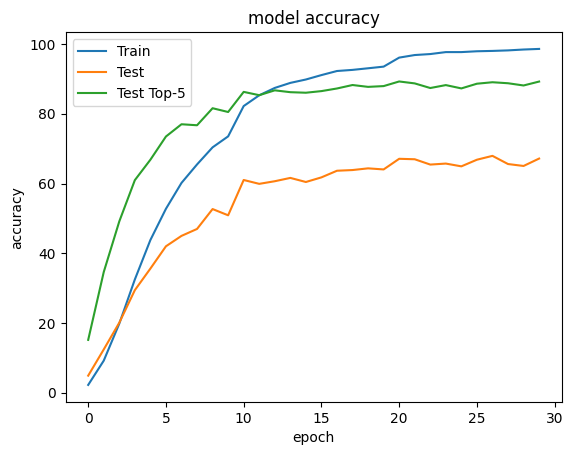

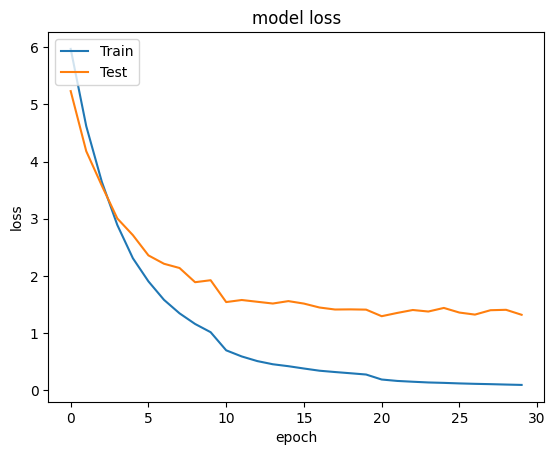

In [1]:
import matplotlib.pyplot as plt
import torch

results = torch.load('/home/osero/Desktop/CMPE/dinov2/classsification/lstm/lstm_results/LSTM_RL_2024-11-20_03-42-19.pth')

# summarize history for accuracy
plt.plot([x * 100 for x in results['avg_accuracy_list'] ]) 
plt.plot(results['avg_test_accuracy_list'])
plt.plot(results['avg_top5_test_accuracy_list'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Test', 'Test Top-5'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(results['avg_loss_list'])
plt.plot(results['avg_test_loss_list'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()